<a href="https://colab.research.google.com/github/geopayme/AstroPhysics/blob/main/Mel_Spectrogram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

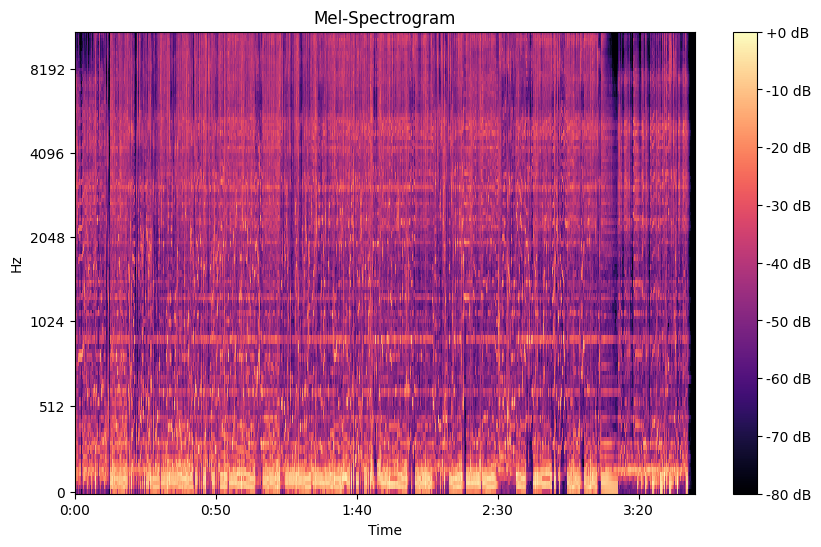

In [ ]:
!pip install librosa tensorflow numpy matplotlib

import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

# Function to load and preprocess audio
def load_and_preprocess_audio(file_path):
    # Load audio file
    audio, sr = librosa.load(file_path, sr=22050)  # Sampling rate set to 22050 Hz
    # Convert audio to Mel-spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmax=8000)  # Corrected argument passing
    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)  # Convert to dB scale
    return mel_spectrogram_db, sr

# Example usage
mel_spectrogram, sr = load_and_preprocess_audio('rust_and_rebellion.mp3')

# Plot the Mel-spectrogram
plt.figure(figsize=(10, 6))
librosa.display.specshow(mel_spectrogram, x_axis='time', y_axis='mel', sr=sr)
plt.title('Mel-Spectrogram')
plt.colorbar(format='%+2.0f dB')
plt.show()



In [ ]:
from tensorflow.keras import layers, models

# Define the more complex Denoising Autoencoder model
def build_complex_dae(input_shape):
    model = models.Sequential()

    # Encoder
    model.add(layers.InputLayer(input_shape=input_shape))
    model.add(layers.Conv2D(64, (5, 5), activation='LeakyReLU(alpha=0.2)', padding='same'))  # Increased kernel size
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2), padding='same'))

    model.add(layers.Conv2D(128, (5, 5), activation='LeakyReLU(alpha=0.2)', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2), padding='same'))

    model.add(layers.Conv2D(256, (3, 3), activation='LeakyReLU(alpha=0.2)', padding='same'))  # Additional layer
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2), padding='same'))

    # Decoder
    model.add(layers.Conv2DTranspose(256, (3, 3), activation='LeakyReLU(alpha=0.2)', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.UpSampling2D((2, 2)))

    model.add(layers.Conv2DTranspose(128, (5, 5), activation='LeakyReLU(alpha=0.2)', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.UpSampling2D((2, 2)))

    model.add(layers.Conv2DTranspose(64, (5, 5), activation='LeakyReLU(alpha=0.2)', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.UpSampling2D((2, 2)))

    model.add(layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same'))  # Output layer

    return model

# Build the model
input_shape = (128, 130, 1)  # Example Mel-spectrogram dimensions
dae_model = build_complex_dae(input_shape)

# Compile the model with more advanced settings
dae_model.compile(optimizer='adam', loss='mean_squared_error')

# Display the model summary
dae_model.summary()


ValueError: Could not interpret activation function identifier: LeakyReLU(alpha=0.2)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the Denoising Autoencoder model
def build_dae(input_shape):
    model = models.Sequential()
    # Encoder
    model.add(layers.InputLayer(input_shape=input_shape))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2), padding='same'))
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2), padding='same'))

    # Decoder
    model.add(layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.UpSampling2D((2, 2)))
    model.add(layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.UpSampling2D((2, 2)))
    model.add(layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same'))

    return model

# Build the model
input_shape = (128, 130, 1)  # Example Mel-spectrogram dimensions
dae_model = build_dae(input_shape)
dae_model.compile(optimizer='adam', loss='mean_squared_error')

dae_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 130, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 33, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 33, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 66, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 66, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 132, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 132, 1)    │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,449 (1.13 MB)

 Trainable params: 296,449 (1.13 MB)

 Non-trainable params: 0 (0.00 B)